In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv('Bank customer churn.csv')
df = df.drop(['id', 'CustomerId', 'Surname' ], axis=1)
df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]] = df[['NumOfProducts', 'CreditScore', 'Age', 'HasCrCard', 'IsActiveMember', 'Exited', 'Tenure' ]].astype(int)
# df.isna().value_counts() ստուգում ենք NAN արծեքներ կան թե չէ (չկային)

# le =LabelEncoder()
# for_encode = df[["Geography", "Gender"]]

# for col in for_encode:
#     df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=["Geography"], drop_first=False)

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# df['old customers'] = df['Tenure']>=1

#-----------------------------------------

# cat boost ի մեջ սա օգուտա տվել
# accuracy 89,15 f1 74 treshold 0,359
# df['old customers'] = df['Age']>=35 

# cat boost ի մեջ սա օգուտա տվել
# accuracy 89,36 f1 74 treshold 0,388
# df['old customers'] = df['Age']>=40

#LAVAGUYN MODEL
#LIGHTGBM
# accuracy 89,28 f1 74,15 treshold 0,38 
df['old customers'] = df['Age']>=45


#-------------------------------------------

# df['rich'] = df['Balance']>0

# lgbm accuracy hascnuma 89,6% bayc f1 72,5, treshold
# df['rich'] = df['EstimatedSalary']>100000
# df = df.drop(['EstimatedSalary'], axis=1)

#accuracy 89+ f1 73,3
# df['vstaheli'] = df['CreditScore']>650

x = df.drop(['Exited'], axis=1)
y = df['Exited']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
for_scale = ['CreditScore', 'Balance', 'Age','EstimatedSalary']
scaler = StandardScaler()
x_train[for_scale] = scaler.fit_transform(x_train[for_scale])
x_test[for_scale] = scaler.transform(x_test[for_scale])

In [4]:
y.value_counts()

Exited
0    11948
1     3052
Name: count, dtype: int64

In [3]:
model_list = {'Lg' : LogisticRegression(random_state=42, class_weight='balanced').fit(x_train, y_train),
              'DC' : DecisionTreeClassifier(random_state=42).fit(x_train, y_train),
              'RF' : RandomForestClassifier(random_state=42, class_weight='balanced').fit(x_train, y_train),
              'XGB': XGBClassifier(random_state=42).fit(x_train, y_train),
              'Cat': CatBoostClassifier(random_state=42, verbose=0).fit(x_train, y_train),
              'LGBM': LGBMClassifier(random_state=42, verbose=-1).fit(x_train, y_train)}

In [4]:
def model_accuracy(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test)
        print(f'{name}: {accuracy_score(y_test, model_pred)}')

model_accuracy(model_list)

Lg: 0.8253333333333334
DC: 0.8562666666666666
RF: 0.8850666666666667
XGB: 0.8856
Cat: 0.8904
LGBM: 0.8928


In [5]:
def model_f1(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test)
        print(f'{name}: {f1_score(y_test, model_pred)}')
model_f1(model_list)

Lg: 0.6568884232582504
DC: 0.6488599348534202
RF: 0.731798382078407
XGB: 0.7022900763358778
Cat: 0.7103594080338267
LGBM: 0.7196652719665272


In [6]:
xgb = XGBClassifier(random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200, 300],         
     'max_depth': [7, 10],                  
     'learning_rate': [0.01, 0.05, 0.1],      
     'min_child_weight': [1, 3],          
     'subsample': [0.8],          
     'colsample_bytree': [0.8],   
     'scale_pos_weight': [3]   }  

grid = GridSearchCV(xgb, param_grid=param_grid_xgb, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_xgb_params = grid.best_params_
best_xgb_model = grid.best_estimator_

xgb_pred = best_xgb_model.predict(x_test)
print(best_xgb_params)
print(f'f1_xgb : {f1_score(y_test, xgb_pred)}')

{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.8}
f1_xgb : 0.7406931964056482


In [37]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [7,10, 12],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
} 

grid = GridSearchCV(rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_rf_params = grid.best_params_
best_rf_model = grid.best_estimator_

rf_pred = best_rf_model.predict(x_test)

print(f'f1_rf : {f1_score(y_test, rf_pred)}')
print(best_rf_params)


f1_rf : 0.7383647798742138
{'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [35]:
dc = DecisionTreeClassifier(random_state=42)
param_grid_dc = {
    'max_depth': [ 5, 7, 10, 12, None],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(dc, param_grid=param_grid_dc, cv=5, scoring='f1', n_jobs=-1).fit(x_train, y_train)

best_dc_params = grid.best_params_
best_dc_model = grid.best_estimator_

dc_pred = best_dc_model.predict(x_test)

print(f'f1_dc : {f1_score(y_test, dc_pred)}')
print(best_dc_params)




f1_dc : 0.7021028037383178
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 25}


In [93]:
lgbm = LGBMClassifier(random_state=42, verbose=-1) 
lgbm_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 1],
    'num_leaves': [30, 50, 70],
    'subsample': [0.6, 0.8, 1]
}

grid = GridSearchCV(lgbm, param_grid=lgbm_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1).fit(x_train, y_train)

best_lgbm_params = grid.best_params_
best_lgbm_model = grid.best_estimator_

lgbm_pred = best_lgbm_model.predict(x_test)
print(f'f1_lgbm : {f1_score(y_test, lgbm_pred)}')
print(best_lgbm_params)



Fitting 5 folds for each of 162 candidates, totalling 810 fits
f1_lgbm : 0.7196652719665272
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.6}


In [10]:
cat = CatBoostClassifier(random_state=42, verbose=0)
cat_param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 1],
    'l2_leaf_reg': [1, 3, 5, 7]
}

grid = GridSearchCV(cat, param_grid=cat_param_grid, cv=5, scoring ='f1', n_jobs=-1, verbose=1).fit(x_train, y_train)

best_cat_params = grid.best_params_
best_cat_model = grid.best_estimator_

cat_pred = best_cat_model.predict(x_test)

print(f'f1_cat : {f1_score(y_test, cat_pred)}')
print(best_cat_params)



Fitting 5 folds for each of 108 candidates, totalling 540 fits
f1_cat : 0.7166077738515901
{'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


In [47]:
after_grid = {'xgb_after_grid' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 10, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_grid' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc after_grid' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm after_grid': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat after_grid' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}

print(model_f1(after_grid))
print(model_accuracy(after_grid))

xgb_after_grid: 0.7360931435963778
rf_after_grid: 0.7351681957186544
dc after_grid: 0.7021028037383178
lgbm after_grid: 0.7146853146853147
cat after_grid: 0.7147912243453645
None
xgb_after_grid: 0.8912
rf_after_grid: 0.8845333333333333
dc after_grid: 0.864
lgbm after_grid: 0.8912
cat after_grid: 0.8925333333333333
None


In [48]:
grid_models = {'xgb_after_grid' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_grid' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc_after_grid' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm_after_grid': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat_after_grid' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}
def Possible_Overfitting(x_train, x_test, y_train, y_test):
    for name, model in grid_models.items():
        train_preds = model.predict(x_train)
        print(f'{name} : {accuracy_score(y_train, train_preds)}')

    for name, model in grid_models.items():
        test_preds = model.predict(x_test)
        print(f'{name}, {accuracy_score(y_test, test_preds)}')

Possible_Overfitting(x_train, x_test, y_train, y_test)

xgb_after_grid : 0.9270222222222222
rf_after_grid : 0.9370666666666667
dc_after_grid : 0.8864888888888889
lgbm_after_grid : 0.924
cat_after_grid : 0.9168
xgb_after_grid, 0.8912
rf_after_grid, 0.8845333333333333
dc_after_grid, 0.864
lgbm_after_grid, 0.8912
cat_after_grid, 0.8925333333333333


In [49]:
after_overfitting = {'xgb_after_overfitting' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train),
'rf_after_overfitting' : RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train),
'dc after_overfitting' : DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train),
'lgbm after_grid': LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train),
'cat after_grid' : CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)}

print(model_f1(after_overfitting))
print(model_accuracy(after_overfitting))

xgb_after_overfitting: 0.7381258023106547
rf_after_overfitting: 0.7351681957186544
dc after_overfitting: 0.7021028037383178
lgbm after_grid: 0.7146853146853147
cat after_grid: 0.7147912243453645
None
xgb_after_overfitting: 0.8912
rf_after_overfitting: 0.8845333333333333
dc after_overfitting: 0.864
lgbm after_grid: 0.8912
cat after_grid: 0.8925333333333333
None


In [36]:
xgb_after_overfitting = XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.01, max_depth= 9, min_child_weight= 3, n_estimators= 100, scale_pos_weight=3, subsample= 0.8).fit(x_train, y_train)
rf_after_overfitting = RandomForestClassifier(class_weight= 'balanced_subsample', max_depth= 14, min_samples_leaf= 2, min_samples_split= 12, n_estimators= 150, random_state=42).fit(x_train, y_train)
dc_after_overfitting = DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=7, min_samples_leaf=2,  min_samples_split=25).fit(x_train, y_train)
lgbm_after_overfitting = LGBMClassifier(random_state=42, verbose=-1, learning_rate= 0.1, max_depth= 5, n_estimators= 100, num_leaves=50, subsample=0.6).fit(x_train, y_train)
cat_after_overfitting = CatBoostClassifier(random_state=42, verbose=0, depth= 4, iterations= 200, l2_leaf_reg= 5, learning_rate=0.1).fit(x_train, y_train)


In [264]:
y_proba = xgb_after_overfitting.predict_proba(x_test)[:, 1]
threshold = 0.5
xgb_pred_new = (y_proba >= threshold).astype(int)
print('xgb f1_score after treshhold:' , f1_score(y_test, xgb_pred_new))
print('xgb accuracy  after treshhold:' , accuracy_score(y_test, xgb_pred_new))

xgb f1_score after treshhold: 0.7355584082156611
xgb accuracy  after treshhold: 0.8901333333333333


In [268]:
y_proba = rf_after_overfitting.predict_proba(x_test)[:, 1]
threshold = 0.5
rf_pred_new = (y_proba >= threshold).astype(int)
print('rf f1_score after treshhold:' , f1_score(y_test, rf_pred_new))
print('rf accuracy  after treshhold:' , accuracy_score(y_test, rf_pred_new))

rf f1_score after treshhold: 0.7338217338217338
rf accuracy  after treshhold: 0.8837333333333334


In [269]:
y_proba = dc_after_overfitting.predict_proba(x_test)[:, 1]
threshold = 0.75
dc_pred_new = (y_proba >= threshold).astype(int)
print('lg f1_score after treshhold:' , f1_score(y_test, dc_pred_new))
print('lg accuracy  after treshhold:' , accuracy_score(y_test, dc_pred_new))

lg f1_score after treshhold: 0.7120908483633934
lg accuracy  after treshhold: 0.8850666666666667


In [50]:
y_proba = lgbm_after_overfitting.predict_proba(x_test)[:, 1]
threshold = 0.38
lgbm_pred_new = (y_proba >= threshold).astype(int)
print('lgbm f1_score after treshhold:' , f1_score(y_test, lgbm_pred_new))
print('lgbm accuracy  after treshhold:' , accuracy_score(y_test, lgbm_pred_new))

lgbm f1_score after treshhold: 0.7416452442159382
lgbm accuracy  after treshhold: 0.8928


In [457]:
y_proba = cat_after_overfitting.predict_proba(x_test)[:, 1]
threshold = 0.52
cat_pred_new = (y_proba >= threshold).astype(int)
print('xgb f1_score after treshhold:' , f1_score(y_test, cat_pred_new))
print('xgb accuracy  after treshhold:' , accuracy_score(y_test, cat_pred_new))

xgb f1_score after treshhold: 0.7166309778729479
xgb accuracy  after treshhold: 0.8941333333333333


In [51]:
# # Ստեղծում ենք Stratified K-Fold խաչաձև վավերացումը
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Հաշվում ենք F1 score-ը բոլոր ֆոլդերի համար
cv_scores = cross_val_score(lgbm_after_overfitting, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)

print(f'CV F1 scores: {cv_scores}')
print(f'Mean CV F1 score: {cv_scores.mean():.4f}')

CV F1 scores: [0.74761905 0.72509004 0.74152047 0.72617612 0.76505313]
Mean CV F1 score: 0.7411


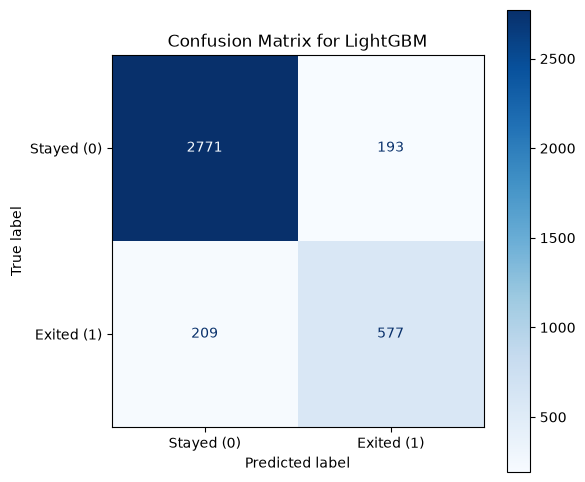

In [52]:
from sklearn.metrics import  ConfusionMatrixDisplay

# Հաշվում ենք մատրիցան թեստային տվյալների վրա
cm = confusion_matrix(y_test, lgbm_pred_new)

# Վիզուալիզացիա
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Exited (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title('Confusion Matrix for LightGBM')
plt.show()

In [53]:
print(classification_report(y_test, lgbm_pred_new))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2964
           1       0.75      0.73      0.74       786

    accuracy                           0.89      3750
   macro avg       0.84      0.83      0.84      3750
weighted avg       0.89      0.89      0.89      3750



In [ ]:
print(roc_auc_score(y_test, lgbm_pred_new))

0.8344909911302038


In [57]:
# Վերցնում ենք դրական դասի (1) հավանականությունները
y_prob = lgbm_after_overfitting.predict_proba(x_test)[:, 1]

# Հիմա արդյունքը կլինի ճիշտ՝ 0.93
print(roc_auc_score(y_test, y_prob))

0.9252158214090717


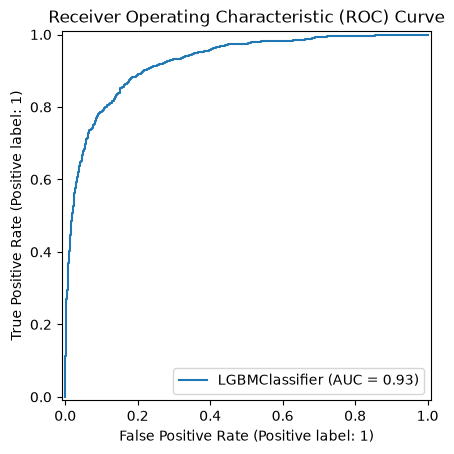

In [56]:
from sklearn.metrics import  RocCurveDisplay
RocCurveDisplay.from_estimator(lgbm_after_overfitting, x_test, y_test)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

In [14]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,old customers
0,678,1,29,4,0.00,3,1,0,180626.36,0,True,False,False,False
1,687,0,34,1,0.00,2,0,1,63736.17,0,True,False,False,False
2,682,0,52,6,0.00,3,0,0,179655.87,1,True,False,False,True
3,753,1,44,6,83347.25,2,1,0,161407.48,0,False,True,False,False
4,544,0,55,0,107747.57,1,1,0,176580.86,1,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,585,1,33,3,0.00,1,1,0,54191.38,0,True,False,False,False
14996,678,1,34,6,0.00,2,1,1,53437.10,0,True,False,False,False
14997,678,0,54,4,0.00,1,1,0,147720.29,1,True,False,False,True
14998,705,0,40,7,0.00,2,1,0,149550.95,0,False,False,True,False


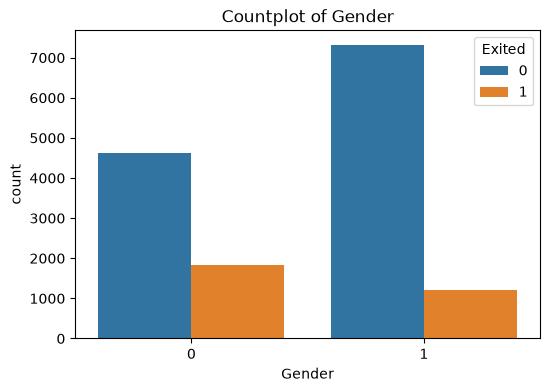

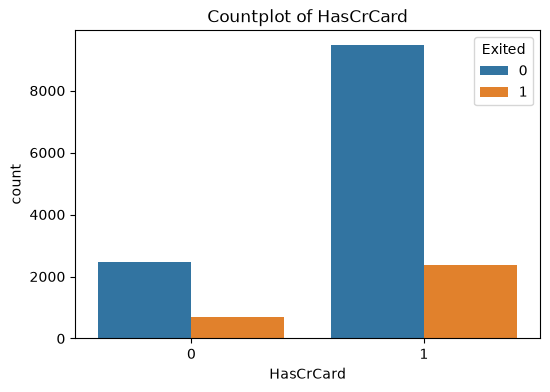

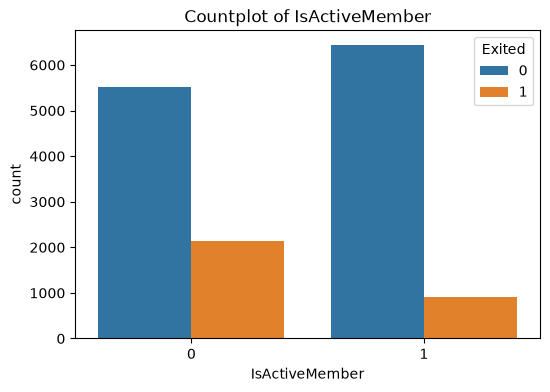

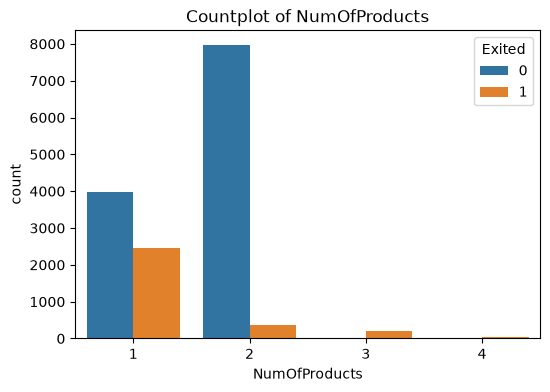

In [15]:
cat_cols = ['Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='Exited')
    plt.title(f'Countplot of {col}')
    plt.show()

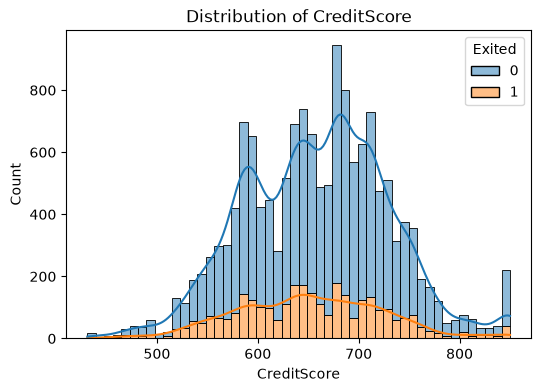

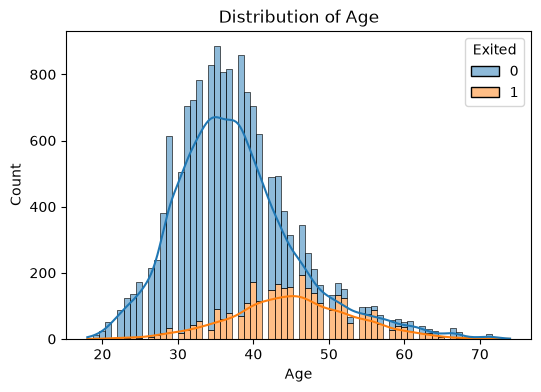

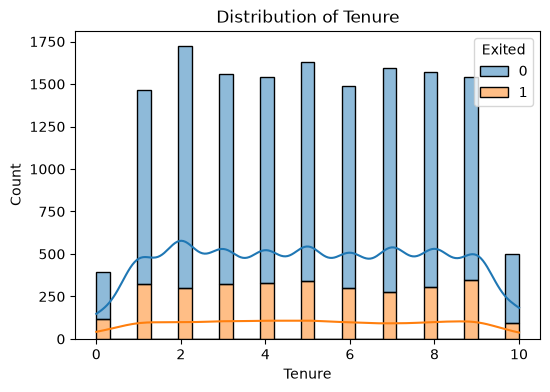

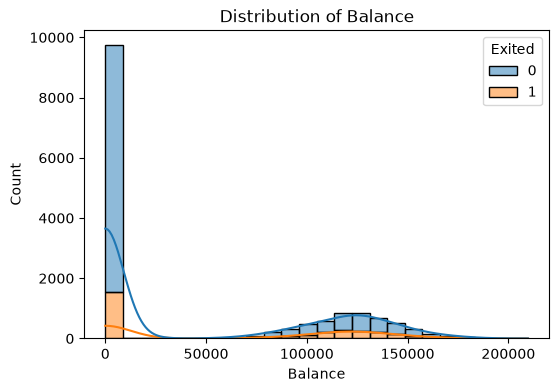

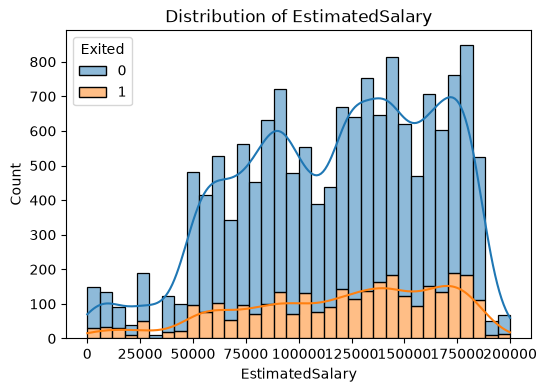

In [16]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Exited', kde=True, multiple='stack')
    plt.title(f'Distribution of {col}')
    plt.show()

In [38]:
importances = pd.Series(lgbm_after_overfitting.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False)

Age                  491
EstimatedSalary      448
CreditScore          432
Balance              347
Tenure               191
NumOfProducts        189
IsActiveMember       124
Gender               119
Geography_Germany     91
HasCrCard             44
Geography_Spain       22
Geography_France      16
old customers          2
dtype: int32